# 1. 세상의 거의모든 머신러닝 알고리즘

딥러닝은 일반적으로 과적합을 피하기 위해 많은 데이터가 필요하다. 데이터가 딥러닝을 구현하기에 충분하게 확보되지 않았거나 빠른 결과가 필요하다면 간단한 머신러닝 기법을 이용하는 것이 더 바람직하다.

# 2. 실습을 위한 준비 사항

피마 인디언 당뇨병 데이터셋을 사용한다.

실습| 데이터 스케일링 및 학습셋, 테스트셋 준비하기

fatal: destination path 'data' already exists and is not an empty directory.


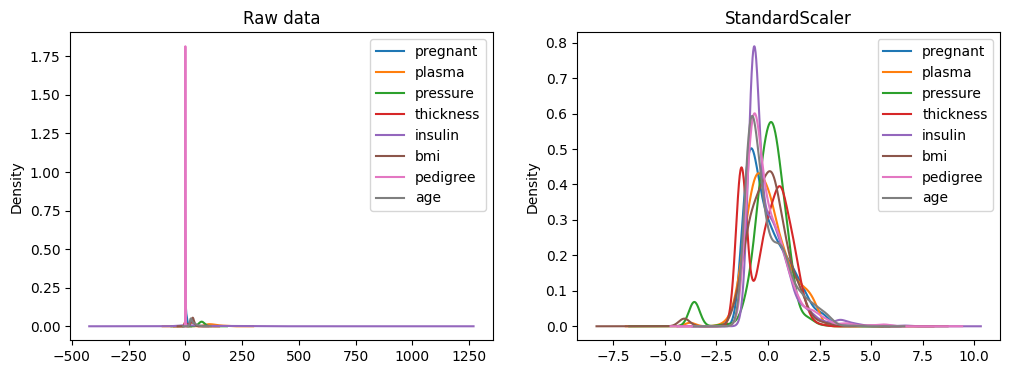

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from matplotlib import pyplot
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data.git

# 피마 인디언 당뇨병 데이터셋을 불러온다.
df = pd.read_csv('./data/pima-indians-diabetes3.csv')

# 세부 정보를 X로 지정한다.
X = df.iloc[:, 0:8]

# 당뇨병 여부를 y로 지정한다.
y = df.iloc[:, 8]

ss = StandardScaler()
scaled_X = pd.DataFrame(ss.fit_transform(X), columns=X.columns)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
X.plot(kind='kde', title='Raw data', ax=ax[0])
scaled_X.plot(kind='kde', title='StandardScaler', ax=ax[1])
plt.show()

# 학습셋과 테스트셋 75:25의 비율로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

왼쪽에 보이는 데이터 스케일링 이전의 그림은 데이터가 너무 편협하게 분포되어 있고 그래프 간 차이가 심하다. 하지만 오른쪽에 보이는 데이터 스케일링 이후의 그림은 데이터가 0을 중심으로 모여 있고 그래프 간의 차이도 심하지 않는다.

# 3. 결정 트리

결정 트리(decision tree)는 '예/아니요'라는 답이 나오는 질문을 계속해서 물으며 학습하는 방법이다.

In [2]:
# 결정 트리 분류기를 불러온다.
from sklearn.tree import DecisionTreeClassifier

# 학습 환경을 설정한다.
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 68.42 %
Standard Deviation: 4.19 %


열 개의 서브셋으로 나누어 학습과 테스트를 각각 실시했고 mean()을 통해 정확도를, std()를 통해 표준편차를 구했다.

# 4. 랜덤 포레스트

랜덤 포레스트(random forest)는 결정 트리를 여러 개 묶어 놓은 것이다.  
즉, 하나의 결정 트리가 아닌, 많은 수의 결정 트리를 실행해 그로부터 나온 분류 결과를 취합해서 최종 예측을 하는 알고리즘이다.

In [3]:
# 랜덤 포레스트 분류기를 불러온다.
from sklearn.ensemble import RandomForestClassifier

# 학습 환경을 설정한다.
classifier = RandomForestClassifier(n_estimators=50)
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f}".format(accuracies.std()*100))

Accuracy: 74.50 %
Standard Deviation: 5.54


여러 개의 결정 트리를 이용해 학습하는 랜덤 포레스트는 앙상블 기법의 대표적인 방법이다.  
n_estimators를 사용해 몇 개의 결정 트리를 사용할 것인지 결정한다.

# 5. 가우시안 나이브 베이즈

가우시안 나이브 베이즈(gaussian naive bayes)는 속성이 연속형 변수일 때, 베이즈 정리를 각 범주에 속할 확률을 계산하는 방법이다.

In [4]:
# 가우시안 나이브 베이즈 분류기를 불러온다.
from sklearn.naive_bayes import GaussianNB

# 학습 환경을 설정한다.
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 74.45 %
Standard Deviation: 6.77 %


# 6. k-최근접 이웃

k-최근접 이웃(k-nearest neighbors)은 새로운 데이터가 입력되면 가장 가까이 있는 것을 중심으로 새로운 데이터의 종류를 정해주는 것이다.

In [5]:
# k-최근접 이웃 분류기를 불러온다.
from sklearn.neighbors import KNeighborsClassifier

# 학습 환경을 설정한다.
classifier = KNeighborsClassifier()
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 69.81 %
Standard Deviation: 5.86 %


이 알고리즘은 k의 수를 변경해 가면서 새로운 데이터를 예측하는 방법이므로 k 값을 잘 정하는 것이 중요하다.  
적절한 범위의 k 값을 바꾸어 입력해 가며 최적의 값을 선택하는 과정이 필요하다.

# 7. 에이다 부스트

에이다 부스트(ada boost)는 여러 번의 분류를 통해 정답을 예측해 가는 알고리즘이다.

In [6]:
from sklearn.ensemble import AdaBoostClassifier

# 학습 환경을 설정한다.
classifier = AdaBoostClassifier()
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 74.13 %
Standard Deviation: 3.74 %


에이다 부스트는 여러 개의 약한 분류기를 사용해 강력한 모델을 만드는 방법으로 앙상블 분류기에 해당한다.  
앙상블 방법의 대표적인 두 가지는 이처럼 이전 분류기의 결과를 서로 연결하는 방식의 부스팅(boosting) 방법과, 여러 분류기를 따로따로 훈련한 후 다수의 결과를 통해 최종 결과를 정하는 배깅(bagging) 방법이 있다.

# 8. 이차 판별 분석

이차 판별 분석(quadratic discriminant analysis)은 각 클래스 간의 경계를 결정해 분류하는 방법이다.

In [7]:
# 이차 판별 분석 분류기를 불러온다.
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 학습 환경을 설정한다.
classifier = QuadraticDiscriminantAnalysis()
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 73.25 %
Standard Deviation: 5.68 %


이차 판별 분석은 선형 분류보다 더 많은 데이터가 필요하고 연산량도 증가하지만, 비선형 분류가 가능하다는 장점이 있다.

# 9. 서포트 벡터 머신

서포트 벡터 머신(support vector machine)은 분류를 위한 기준선을 정의하는 모델이다. 마진이 최대화되는 경계를 찾아 분류를 하는 방법이다.

In [8]:
# 서포트 벡터 머신 분류기를 불러온다.
from sklearn.svm import SVC

# 학습 환경을 설정한다.\
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)


# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 75.33 %
Standard Deviation: 4.64 %


SVC 분류기의 옵션으로 kernel을 지정할 수 있는데 'linear'라고 정하면 일반적인 선형 SVM이 동작된다.

# 10. 서포트 벡터 머신 - RBF 커널

In [9]:
# 서포트 벡터 머신 분류기를 불러온다.
from sklearn.svm import SVC

# 학습 환경을 설정한다.
classifier = SVC(kernel='rbf')
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 73.96 %
Standard Deviation: 6.43 %


# 11. 보팅

보팅(voting)은 여러 가지 다른 유형의 알고리즘을 같은 데이터셋에 적용해 학습하는 방법이다. 학습한 결과를 모아 다수의 분류기가 결정한 결과를 선택하거나 클래스별 평균을 종합해 예측한다.

In [10]:
# 보팅 분류기를 불러온다.
from sklearn.ensemble import VotingClassifier

# 학습 환경을 설정한다.
clf1 = AdaBoostClassifier()
clf2 = RandomForestClassifier()
clf3 = SVC(kernel='linear')
classifier = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('gnb', clf3)])
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 74.83 %
Standard Deviation: 3.20 %


# 12. 배깅

배깅(bagging)은 데이터 세트를 여러 개로 분리해 분류를 실행하는 방법이다. 보팅과 차이점은 하나의 알고리즘을 사용한다는 것이고, 부스팅과 차이점은 각 분류기를 제각각 따로 분류한다는 것이다. 배깅 방식은 단일 분류기를 여러 번 사용함으로써 정확도를 높이고 과적합을 방지하는 효과가 있다.  
분류기를 n번 반복해서 데이터가 n번의 서로 다른 학습셋, 데이터셋으로 분리될 때는 부트스트랩(bootstrap) 기법을 사용한다.

In [11]:
# 배깅 분류기를 불러온다.
from sklearn.ensemble import BaggingClassifier

# 학습 환경을 설정한다.
classifier = BaggingClassifier(estimator=SVC(kernel='rbf'), n_estimators=10)
classifier.fit(X_train, y_train)

# 테스트셋에 적용한다.
y_pred = classifier.predict(X_test)

# 계층별 교차 검증 환경을 설정한다.
skf = StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산한다.
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=skf)

# 정확도와 표준편차를 출력한다.
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 73.44 %
Standard Deviation: 3.51 %


# 13. 여러 알고리즘의 성능을 한눈에 비교하기

Mean accuracy of D_tree : 70.13 %
Mean accuracy of RF : 73.47 %
Mean accuracy of GNB : 74.83 %
Mean accuracy of KNN : 70.18 %
Mean accuracy of Ada : 75.72 %
Mean accuracy of SVM_l : 74.66 %
Mean accuracy of SVM_k : 71.35 %
Mean accuracy of Voting : 72.60 %
Mean accuracy of Bagging : 74.65 %


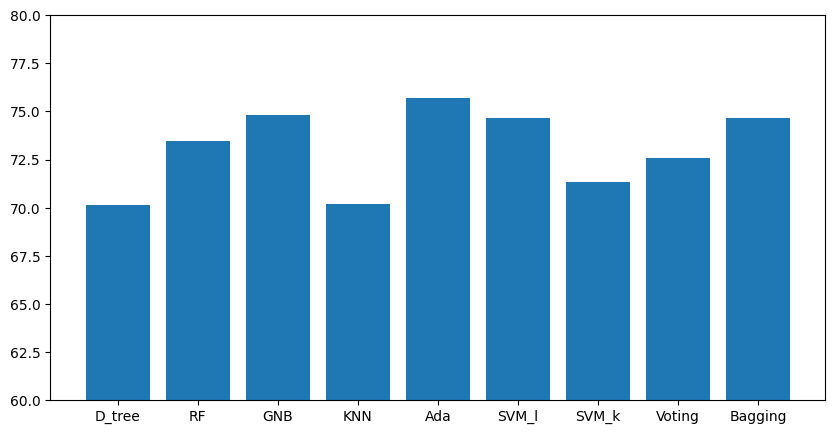

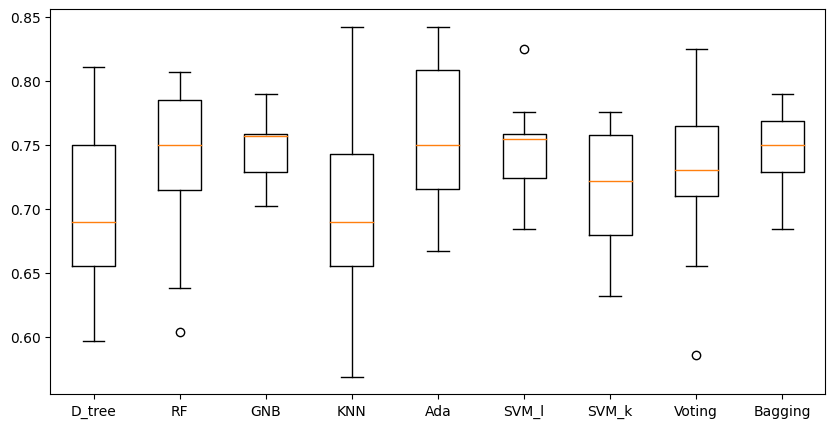

In [12]:
# 사용할 분류기를 모두 지정한다.
classifiers = [DecisionTreeClassifier(),
               RandomForestClassifier(),
               GaussianNB(),
               KNeighborsClassifier(),
               SVC(kernel='linear'),
               SVC(kernel='rbf'),
               AdaBoostClassifier(),
               QuadraticDiscriminantAnalysis(),
               VotingClassifier(estimators=[('1', AdaBoostClassifier()),
                                            ('2', RandomForestClassifier()),
                                            ('3', SVC(kernel='linear'))]),
               BaggingClassifier(estimator=clf3, n_estimators=10, random_state=0)
               ]

# 각 분류기의 이름을 지정한다.
classifier_names = ['D_tree',
                    'RF',
                    'GNB',
                    'KNN',
                    'Ada',
                    'SVM_l',
                    'SVM_k',
                    'Voting',
                    'Bagging'
                    ]

# 결과가 저장될 리스트를 만든다.
modelaccuracies = []
modelmeans = []
modelnames = []

# 각 분류기를 실행해 결과를 저장한다.
classifier_data = zip(classifier_names, classifiers)
for classifier_name, classifier in classifier_data:
    # 계층별 교차 검증 환경을 설정한다.
    skf = StratifiedKFold(n_splits=10, shuffle=True)
    # 교차 검증을 통해 정확도를 계산한다.
    accuracies = cross_val_score(classifier, X=X_train, y=y_train, cv=skf)
    # 정확도의 평균값을 출력한다.
    print("Mean accuracy of", classifier_name, ": {:.2f} %".format(accuracies.mean()*100))
    # 결과를 저장한다.
    modelaccuracies.append(accuracies)
    modelnames.append(classifier_name)
    modelmeans.append(accuracies.mean()*100)

# 분류기별 정확도의 평균값을 막대 그래프로 출력한다.
plt.figure(figsize=(10, 5))
plt.ylim([60, 80])
plt.bar(modelnames, modelmeans)

# 분류기별 결과를 박스 그래프로 출력한다.
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.boxplot(modelaccuracies)
ax.set_xticklabels(modelnames)
plt.show()